* Name - Sharvil Vichare
* Roll NO - B39
* PRN - 2324000814

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

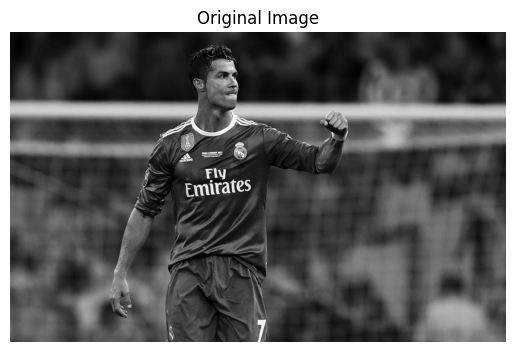

In [ ]:
# Load image (grayscale)
image = cv2.imread('/content/ronaldo.jpg', cv2.IMREAD_GRAYSCALE)

# Display
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

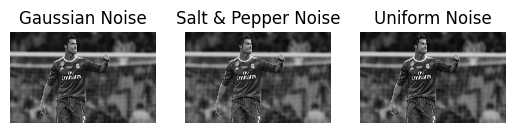

In [ ]:
# Gaussian Noise
gaussian_noise = image + np.random.normal(0, 25, image.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 255).astype(np.uint8)

# Salt & Pepper Noise
sp_noise = image.copy()
prob = 0.05
rand = np.random.rand(*image.shape)
sp_noise[rand < prob/2] = 0
sp_noise[rand > 1 - prob/2] = 255

# Uniform Noise
uniform_noise = image + np.random.uniform(-30, 30, image.shape)
uniform_noise = np.clip(uniform_noise, 0, 255).astype(np.uint8)

# Display all
titles = ['Gaussian Noise', 'Salt & Pepper Noise', 'Uniform Noise']
images = [gaussian_noise, sp_noise, uniform_noise]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

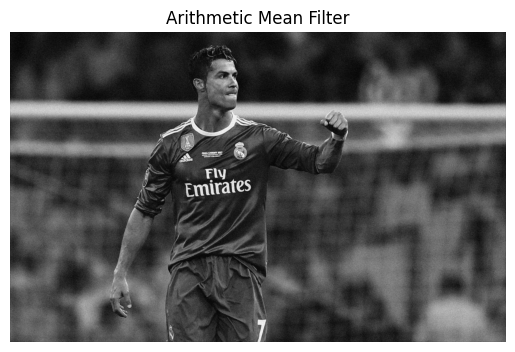

In [ ]:
def arithmetic_mean_filter(img, k=3):
    pad = k // 2
    padded = np.pad(img, pad, mode='constant')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+k, j:j+k]
            output[i, j] = np.mean(window)

    return output

amf_result = arithmetic_mean_filter(gaussian_noise, 3)

plt.imshow(amf_result, cmap='gray')
plt.title('Arithmetic Mean Filter')
plt.axis('off')

/tmp/ipykernel_1491/418800493.py:9: RuntimeWarning: overflow encountered in scalar add
  output[i, j] = (np.max(window) + np.min(window)) / 2


(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

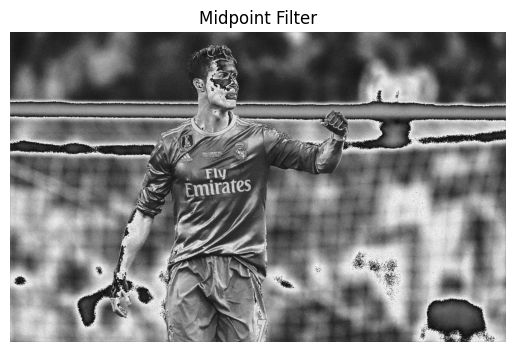

In [ ]:
def midpoint_filter(img, k=3):
    pad = k // 2
    padded = np.pad(img, pad, mode='constant')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+k, j:j+k]
            output[i, j] = (np.max(window) + np.min(window)) / 2

    return output.astype(np.uint8)

mid_result = midpoint_filter(uniform_noise, 3)

plt.imshow(mid_result, cmap='gray')
plt.title('Midpoint Filter')
plt.axis('off')

(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

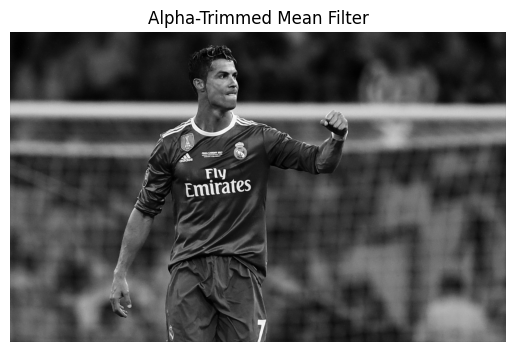

In [ ]:
 def alpha_trimmed_filter(img, k=3, d=4):
    pad = k // 2
    padded = np.pad(img, pad, mode='constant')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i:i+k, j:j+k].flatten()
            sorted_vals = np.sort(window)

            trimmed = sorted_vals[d//2 : len(sorted_vals) - d//2]
            output[i, j] = np.mean(trimmed)

    return output.astype(np.uint8)

alpha_result = alpha_trimmed_filter(sp_noise, 3, d=4)

plt.imshow(alpha_result, cmap='gray')
plt.title('Alpha-Trimmed Mean Filter')
plt.axis('off')

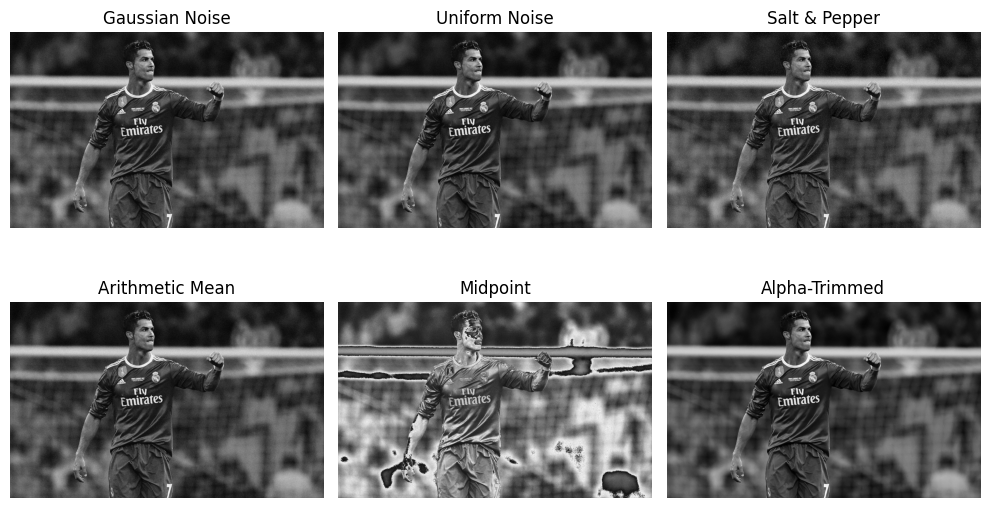

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
plt.imshow(gaussian_noise, cmap='gray')
plt.title('Gaussian Noise')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(uniform_noise, cmap='gray')
plt.title('Uniform Noise')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sp_noise, cmap='gray')
plt.title('Salt & Pepper')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(amf_result, cmap='gray')
plt.title('Arithmetic Mean')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(mid_result, cmap='gray')
plt.title('Midpoint')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(alpha_result, cmap='gray')
plt.title('Alpha-Trimmed')
plt.axis('off')

plt.tight_layout()
plt.show()